# Respiratory Diagnosis Modeling Pipeline

This notebook is organized into parts: environment setup, data loading, feature engineering, split strategy, model training, and evaluation.

Goal: build a robust multi-class classifier for respiratory diagnosis while keeping the workflow reproducible and interpretable.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from scipy.spatial.distance import cdist
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, StackingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, fbeta_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

## Part 0. Experiment Configuration

Centralized constants for split ratio, random seed, CV folds, and model hyperparameters.

## Part 1. Environment and Dependencies

Install optional packages and prepare paths for loading the dataset in Colab/local runtime.

In [ ]:
CONFIG = {
    'random_seed': 42,
    'test_size': 0.2,
    'cv_folds': 5,
    'cvae_epochs': 250,
    'threshold_grid_low': 0.01,
    'threshold_grid_high': 0.7,
    'threshold_grid_steps': 70,
    'max_infection_threshold': 0.18,
}

np.random.seed(CONFIG['random_seed'])
torch.manual_seed(CONFIG['random_seed'])

print('Config loaded:', CONFIG)

In [2]:
!pip install catboost
!pip install optuna

In [3]:
REPO_PATH = Path('/content/course_paper')

!git clone --depth 1 --filter=blob:none --sparse https://github.com/incRED1bl/course_paper.git {REPO_PATH}
!git -C {REPO_PATH} sparse-checkout set colab/data/respiratory_features.csv

sys.path.insert(0, str(REPO_PATH))

!cp {REPO_PATH}/colab/data/respiratory_features.csv ../../data/respiratory_features.csv

fatal: destination path '/content/course_paper' already exists and is not an empty directory.
cp: cannot create regular file '../../data/respiratory_features.csv': No such file or directory


## Part 2. Data Loading and Basic Cleaning

Load feature table, remove metadata columns, and keep only labeled diagnoses.

In [4]:
df = pd.read_csv('/content/course_paper/colab/data/respiratory_features.csv')
df.head()

,filename,patient_id,low_freq_energy,mid_freq_energy,high_freq_energy,whistle_strength,spectral_centroid,peak_frequency,entropy,complexity,diagnosis
0,101_1b1_Al_sc_Meditron.wav,101,0.638772,0.061506,0.299722,0.027502,2317.564152,21.533203,0.815790,0.146400,Unknown
1,101_1b1_Pr_sc_Meditron.wav,101,0.853642,0.026700,0.119657,0.029523,934.166042,0.000000,0.884253,0.097903,Unknown
2,102_1b1_Ar_sc_Meditron.wav,102,0.697796,0.135208,0.166997,0.034458,1253.170052,0.000000,0.898144,0.087052,Healthy
3,103_2b2_Ar_mc_LittC2SE.wav,103,0.658031,0.058343,0.283626,0.027033,2190.655897,0.000000,0.868986,0.110194,Asthma
4,104_1b1_Al_sc_Litt3200.wav,104,0.954556,0.037111,0.008333,0.046673,81.716123,0.000000,0.647283,0.233463,COPD


In [5]:
df = df.drop(columns=['filename', 'patient_id'])
df = df[df['diagnosis'] != 'Unknown']
df.head()

,low_freq_energy,mid_freq_energy,high_freq_energy,whistle_strength,spectral_centroid,peak_frequency,entropy,complexity,diagnosis
2,0.697796,0.135208,0.166997,0.034458,1253.170052,0.0000,0.898144,0.087052,Healthy
3,0.658031,0.058343,0.283626,0.027033,2190.655897,0.0000,0.868986,0.110194,Asthma
4,0.954556,0.037111,0.008333,0.046673,81.716123,0.0000,0.647283,0.233463,COPD
5,0.799876,0.187994,0.012130,0.044284,198.766348,7.8125,0.701699,0.210539,COPD
6,0.885614,0.090175,0.024211,0.015177,211.954439,15.6250,0.637505,0.237087,COPD


In [6]:
display(df['diagnosis'].value_counts())

,count
diagnosis,
COPD,793
Pneumonia,37
Healthy,35
URTI,21
Bronchiectasis,16
Bronchiolitis,13
LRTI,2
Asthma,1


## Part 3. Feature Engineering

Create relational acoustic features and class-distance features to enrich representation before model training.

In [7]:
def engineer_relational_features(df):
    new_df = df.copy()
    eps = 1e-6
    new_df['high_low_ratio'] = new_df['high_freq_energy'] / (new_df['low_freq_energy'] + eps)
    new_df['mid_low_ratio'] = new_df['mid_freq_energy'] / (new_df['low_freq_energy'] + eps)
    new_df['whistle_complexity_product'] = new_df['whistle_strength'] * new_df['complexity']
    new_df['centroid_peak_diff'] = new_df['spectral_centroid'] - new_df['peak_frequency']
    new_df['centroid_peak_ratio'] = new_df['spectral_centroid'] / (new_df['peak_frequency'] + eps)
    new_df['entropy_complexity_interaction'] = new_df['entropy'] * new_df['complexity']

    new_df = new_df.replace([np.inf, -np.inf], np.nan).fillna(0)
    return new_df



In [8]:
def add_class_distance_features(train_df, test_df, feature_cols, target_col='diagnosis'):
    dist_scaler = StandardScaler()
    train_scaled = dist_scaler.fit_transform(train_df[feature_cols])
    test_scaled = dist_scaler.transform(test_df[feature_cols])

    centroids = train_df.groupby(target_col)[feature_cols].mean()
    centroids_scaled = dist_scaler.transform(centroids)

    dist_train = cdist(train_scaled, centroids_scaled, metric='euclidean')
    dist_test = cdist(test_scaled, centroids_scaled, metric='euclidean')

    dist_cols = [f'dist_to_{cls}' for cls in centroids.index]
    df_dist_train = pd.DataFrame(dist_train, columns=dist_cols, index=train_df.index)
    df_dist_test = pd.DataFrame(dist_test, columns=dist_cols, index=test_df.index)

    return pd.concat([train_df, df_dist_train], axis=1), pd.concat([test_df, df_dist_test], axis=1)




In [9]:
class CVAE(nn.Module):
    def __init__(self, feature_dim, class_dim, latent_dim=4):
        super(CVAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(feature_dim + class_dim, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim * 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + class_dim, 32),
            nn.ReLU(),
            nn.Linear(32, feature_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, c):
        inputs = torch.cat([x, c], dim=1)
        h = self.encoder(inputs)
        mu, logvar = torch.chunk(h, 2, dim=1)
        z = self.reparameterize(mu, logvar)
        z_cond = torch.cat([z, c], dim=1)
        return self.decoder(z_cond), mu, logvar

In [10]:
def train_cvae_module(X_train, y_enc, epochs=250):
    feature_dim = X_train.shape[1]
    class_dim = len(np.unique(y_enc))

    model = CVAE(feature_dim, class_dim)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    x_tensor = torch.FloatTensor(X_train.values)
    c_tensor = torch.FloatTensor(np.eye(class_dim)[y_enc])

    model.train()
    for epoch in range(epochs):
        recon_x, mu, logvar = model(x_tensor, c_tensor)
        recon_loss = nn.functional.mse_loss(recon_x, x_tensor, reduction='sum')
        kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + kld_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return model



In [11]:
def generate_borderline_samples(model, class_idx, num_samples, class_dim, feature_names, sigma=1.5):
    model.eval()
    with torch.no_grad():
        c = torch.zeros(num_samples, class_dim)
        c[:, class_idx] = 1
        z = torch.randn(num_samples, 4) * sigma
        z_cond = torch.cat([z, c], dim=1)
        samples = model.decoder(z_cond).numpy()
    return pd.DataFrame(samples, columns=feature_names)

## Part 4. Train/Test Split Strategy

Use stratified 80/20 split on diagnosis labels, then derive distance-based features from train centroids and apply them to test set.

This prevents leakage: class centroids are fitted on train data only.

In [ ]:
df_eng = engineer_relational_features(df)

counts = df_eng['diagnosis'].value_counts()
rare_to_fix = counts[counts < 2].index.tolist()
if rare_to_fix:
    duplicates = df_eng[df_eng['diagnosis'].isin(rare_to_fix)].copy()
    df_eng = pd.concat([df_eng, duplicates], axis=0).reset_index(drop=True)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df_eng,
    df_eng['diagnosis'],
    test_size=CONFIG['test_size'],
    stratify=df_eng['diagnosis'],
    random_state=CONFIG['random_seed'],
)

feat_cols = X_train_raw.drop(columns=['diagnosis']).columns.tolist()
X_train_dist, X_test_dist = add_class_distance_features(X_train_raw, X_test_raw, feat_cols)

le = LabelEncoder()
y_train_enc = le.fit_transform(X_train_dist['diagnosis'])
y_test_enc = le.transform(X_test_dist['diagnosis'])

X_train_final = X_train_dist.drop(columns=['diagnosis'])
X_test_final = X_test_dist.drop(columns=['diagnosis'])

X_train_to_fit = X_train_final.copy()
y_train_to_fit = y_train_enc.copy()

In [ ]:
assert len(X_train_to_fit) == len(y_train_to_fit), 'Train X/y length mismatch.'
assert len(X_test_final) == len(y_test_enc), 'Test X/y length mismatch.'
assert 'diagnosis' not in X_train_to_fit.columns, 'Target leakage: diagnosis column found in training features.'

print('Sanity check passed: split outputs are shape-consistent.')
print('Train shape:', X_train_to_fit.shape, '| Test shape:', X_test_final.shape)
print('Encoded train class counts:\n', pd.Series(y_train_to_fit).value_counts().sort_index())

## Part 5. Optional CVAE Augmentation

Train CVAE on tabular features. Synthetic sample generation is optional and currently left commented to keep baseline reproducible.

In [ ]:
cvae_model = train_cvae_module(
    X_train_to_fit,
    y_train_to_fit,
    epochs=CONFIG['cvae_epochs'],
)

In [14]:
#Data augmentation(Optional)


# train_full = X_train_final.copy()
# train_full['target'] = y_train_enc

# rare_classes = ['Pneumonia', 'URTI', 'Bronchiectasis', 'Bronchiolitis', 'Asthma', 'Healthy']
# target_count = 200

# synthetic_list = [train_full]

# for cls_name in rare_classes:
#     if cls_name in le.classes_:
#         idx = list(le.classes_).index(cls_name)
#         gen_df = generate_borderline_samples(cvae_model, idx, target_count, len(le.classes_), X_train_final.columns, sigma=1.2)
#         gen_df['target'] = idx
#         synthetic_list.append(gen_df)

# df_augmented_final = pd.concat(synthetic_list, axis=0).reset_index(drop=True)

# X_train_to_fit = df_augmented_final.drop(columns=['target'])
# y_train_to_fit = df_augmented_final['target']

# print(f"Sync Check: X rows = {len(X_train_to_fit)}, y rows = {len(y_train_to_fit)}")

In [15]:
def macro_sensitive_predict(probs, labels_list, threshold_sick=0.12):
    name_to_idx = {name: i for i, name in enumerate(labels_list)}

    infection_cluster = ['Pneumonia', 'URTI', 'LRTI']
    obstructive_cluster = ['Bronchiectasis', 'Bronchiolitis', 'Asthma']

    inf_indices = [name_to_idx[n] for n in infection_cluster if n in name_to_idx]
    obs_indices = [name_to_idx[n] for n in obstructive_cluster if n in name_to_idx]

    final_preds = np.argmax(probs, axis=1)

    for i in range(len(probs)):
        max_inf_prob = np.max(probs[i][inf_indices]) if inf_indices else 0
        max_obs_prob = np.max(probs[i][obs_indices]) if obs_indices else 0

        if max_inf_prob > threshold_sick:
            final_preds[i] = inf_indices[np.argmax(probs[i][inf_indices])]
        elif max_obs_prob > threshold_sick:
            final_preds[i] = obs_indices[np.argmax(probs[i][obs_indices])]

    return final_preds

## Part 6. Preprocessing and Label Construction

Impute missing values, scale features, and build hierarchical binary targets used by specialist expert models.

In [ ]:
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_imputed = imputer.fit_transform(X_train_to_fit)
X_test_imputed = imputer.transform(X_test_final)

X_train_scaled_array = scaler.fit_transform(X_train_imputed)
X_test_scaled_array = scaler.transform(X_test_imputed)

X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=X_train_to_fit.columns)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=X_train_to_fit.columns)

def get_hierarchical_labels(y_encoded, label_encoder):
    classes = label_encoder.classes_
    infection_labels = ['Pneumonia', 'URTI', 'LRTI']
    y_is_sick = np.array([0 if classes[i] == 'Healthy' else 1 for i in y_encoded])
    y_is_infection = np.array([1 if classes[i] in infection_labels else 0 for i in y_encoded])
    y_is_copd = np.array([1 if classes[i] == 'COPD' else 0 for i in y_encoded])
    return y_is_sick, y_is_infection, y_is_copd

y_sick_train, y_inf_train, y_copd_train = get_hierarchical_labels(y_train_to_fit, le)

print(f'Training data prepared: {X_train_scaled.shape}')

Данные готовы. Обучающая выборка (DF): (735, 22)


In [ ]:
assert not np.isnan(X_train_scaled.values).any(), 'NaN values present in X_train_scaled.'
assert not np.isnan(X_test_scaled.values).any(), 'NaN values present in X_test_scaled.'

print('Sanity check passed: scaled matrices contain no NaN values.')

In [ ]:
level0_ultimate = [
    ('xgb', xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.02, random_state=42)),
    ('lgbm', lgb.LGBMClassifier(n_estimators=300, learning_rate=0.02, random_state=42, verbose=-1)),
    ('et', ExtraTreesClassifier(n_estimators=300, class_weight='balanced', random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)),
    ('svc', SVC(probability=True, class_weight='balanced', C=5, random_state=42)),
    ('cat', CatBoostClassifier(iterations=300, depth=5, learning_rate=0.02, silent=True, random_state=42)),
]

def make_calibrated_expert(base_model, method='sigmoid'):
    return CalibratedClassifierCV(base_model, method=method, cv=3)

base_rf = RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample', random_state=42)
base_xgb = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)

print(f'Stacking architecture ready. Models in level-0: {len(level0_ultimate)}')

Архитектура готова. Моделей в стеке: 6


In [ ]:
print('Training Expert 1: disease detector...')
model_sick = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced_subsample',
    max_depth=10,
    random_state=42,
 )
model_sick = CalibratedClassifierCV(model_sick, method='sigmoid', cv=3)
model_sick.fit(X_train_scaled, y_sick_train)

Прокачка Эксперта №1: Детектор болезней...


CalibratedClassifierCV(cv=3,
                       estimator=RandomForestClassifier(class_weight='balanced_subsample',
                                                        max_depth=10,
                                                        n_estimators=300,
                                                        random_state=42))

In [ ]:
print('Training Expert 2: infection detector...')

model_inf_base = CatBoostClassifier(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    auto_class_weights='SqrtBalanced',
    l2_leaf_reg=10,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    silent=True,
    random_state=42,
 )

model_inf = CalibratedClassifierCV(model_inf_base, method='sigmoid', cv=3)
model_inf.fit(X_train_scaled, y_inf_train)

Эксперт №2: Проверка CatBoost...


CalibratedClassifierCV(cv=3,
                       estimator=CatBoostClassifier(auto_class_weights='SqrtBalanced', bootstrap_type='Bernoulli', depth=6, iterations=800, l2_leaf_reg=10, learning_rate=0.03, random_state=42, silent=True, subsample=0.8))

In [ ]:
print('Training Expert 3: COPD detector...')

lgbm_copd_base = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1,
 )

model_copd = CalibratedClassifierCV(lgbm_copd_base, method='sigmoid', cv=3)
model_copd.fit(X_train_scaled, y_copd_train)

print('Expert 3 is trained.')

Прокачка Эксперта №3: Снайпер по COPD (Corrected)...
Эксперт №3 обучен правильно. Ошибок имен быть не должно.


In [ ]:
label_map_3 = {
    'Healthy': 0,
    'COPD': 1,
    'Asthma': 1,
    'Bronchiectasis': 1,
    'Pneumonia': 2,
    'URTI': 2,
    'LRTI': 2,
    'Bronchiolitis': 2,
}

y_train_3class = np.array([label_map_3[label] for label in le.inverse_transform(y_train_to_fit)])
y_test_3class = np.array([label_map_3[label] for label in le.inverse_transform(y_test_enc)])

In [ ]:
print('Training final 3-class stack...')

meta_learner = LogisticRegression(
    class_weight='balanced',
    max_iter=3000,
    random_state=42,
 )

model_multi_3 = StackingClassifier(
    estimators=level0_ultimate,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
 )

model_multi_3.fit(X_train_scaled, y_train_3class)

print('3-class stack is ready: Healthy / Chronic / Infectious.')

Обучение ультимативного 3-классового стека...
3-классовый стек готов. Теперь он видит мир в категориях: Здоров / Хроник / Инфекция.


## Part 7. Stacking, Thresholding, and Cross-Validation

Train specialists and final 3-class stack, then evaluate using macro-F1 and confusion matrices in stratified CV.

In [ ]:
def find_medical_threshold(y_true, y_probs):
    thresholds = np.linspace(
        CONFIG['threshold_grid_low'],
        CONFIG['threshold_grid_high'],
        CONFIG['threshold_grid_steps'],
    )
    best_f2 = 0.0
    best_threshold = 0.2

    for threshold in thresholds:
        preds = (y_probs >= threshold).astype(int)
        score = fbeta_score(y_true, preds, beta=2, zero_division=0)
        if score > best_f2:
            best_f2 = score
            best_threshold = threshold
    return best_threshold

def predict_3class(
    features,
    model_sick,
    model_inf,
    model_copd,
    model_multi_3,
    threshold_sick,
    threshold_inf,
    threshold_copd,
 ):
    prob_sick = model_sick.predict_proba(features)[:, 1]
    prob_inf = model_inf.predict_proba(features)[:, 1]
    prob_copd = model_copd.predict_proba(features)[:, 1]
    base_pred = model_multi_3.predict(features)

    final_pred = base_pred.copy()
    for i in range(len(base_pred)):
        if prob_sick[i] < threshold_sick:
            final_pred[i] = 0
        else:
            if prob_inf[i] >= threshold_inf:
                final_pred[i] = 2
            elif prob_copd[i] >= threshold_copd:
                final_pred[i] = 1
    return final_pred

t_sick = find_medical_threshold(y_sick_train, model_sick.predict_proba(X_train_scaled)[:, 1])
t_inf = find_medical_threshold(y_inf_train, model_inf.predict_proba(X_train_scaled)[:, 1])
t_copd = find_medical_threshold(y_copd_train, model_copd.predict_proba(X_train_scaled)[:, 1])

t_inf = min(t_inf, CONFIG['max_infection_threshold'])

print(f'Medical thresholds (F2): Sick={t_sick:.2f}, Inf={t_inf:.2f}, COPD={t_copd:.2f}')

Медицинские пороги (F2): Sick=0.67, Inf=0.18, COPD=0.50


In [ ]:
y_3class_full = np.array([label_map_3[c] for c in le.inverse_transform(y_train_to_fit)])

skf = StratifiedKFold(
    n_splits=CONFIG['cv_folds'],
    shuffle=True,
    random_state=CONFIG['random_seed'],
)
total_cm = np.zeros((3, 3), dtype=int)
fold_f1 = []

print('Running optimized 5-fold CV...')

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_to_fit, y_3class_full), 1):
    X_fold_train = X_train_to_fit.iloc[train_idx]
    X_fold_val = X_train_to_fit.iloc[val_idx]
    y_fold_train = y_train_to_fit[train_idx]
    y_fold_val = y_train_to_fit[val_idx]

    y_fold_train_3 = y_3class_full[train_idx]
    y_fold_val_3 = y_3class_full[val_idx]

    cv_imputer = SimpleImputer(strategy='median')
    cv_scaler = StandardScaler()

    X_fold_train_sc = pd.DataFrame(
        cv_scaler.fit_transform(cv_imputer.fit_transform(X_fold_train)),
        columns=X_fold_train.columns,
    )
    X_fold_val_sc = pd.DataFrame(
        cv_scaler.transform(cv_imputer.transform(X_fold_val)),
        columns=X_fold_train.columns,
    )

    y_sick_fold, y_inf_fold, y_copd_fold = get_hierarchical_labels(y_fold_train, le)

    m_sick_cv = make_calibrated_expert(
        RandomForestClassifier(n_estimators=200, class_weight='balanced')
    ).fit(X_fold_train_sc, y_sick_fold)

    m_inf_cv = make_calibrated_expert(clone(base_xgb)).fit(X_fold_train_sc, y_inf_fold)

    m_copd_cv = make_calibrated_expert(
        lgb.LGBMClassifier(n_estimators=300, class_weight='balanced', verbose=-1)
    ).fit(X_fold_train_sc, y_copd_fold)

    m_stack_cv = StackingClassifier(
        estimators=level0_ultimate,
        final_estimator=LogisticRegression(class_weight='balanced', max_iter=3000),
        cv=3,
        n_jobs=-1,
    ).fit(X_fold_train_sc, y_fold_train_3)

    ts = find_medical_threshold(y_sick_fold, m_sick_cv.predict_proba(X_fold_train_sc)[:, 1])
    ti = find_medical_threshold(y_inf_fold, m_inf_cv.predict_proba(X_fold_train_sc)[:, 1])
    tc = find_medical_threshold(y_copd_fold, m_copd_cv.predict_proba(X_fold_train_sc)[:, 1])

    y_pred = predict_3class(
        X_fold_val_sc,
        m_sick_cv,
        m_inf_cv,
        m_copd_cv,
        m_stack_cv,
        ts,
        ti,
        tc,
    )

    total_cm += confusion_matrix(y_fold_val_3, y_pred, labels=[0, 1, 2])
    fold_f1.append(f1_score(y_fold_val_3, y_pred, average='macro'))

    print(f'Fold {fold} done.')

print(f'CV macro-F1 mean: {np.mean(fold_f1):.4f} +/- {np.std(fold_f1):.4f}')

Запуск оптимизированной 5-fold CV...
Фолд 1 готов.
Фолд 2 готов.
Фолд 3 готов.
Фолд 4 готов.
Фолд 5 готов.


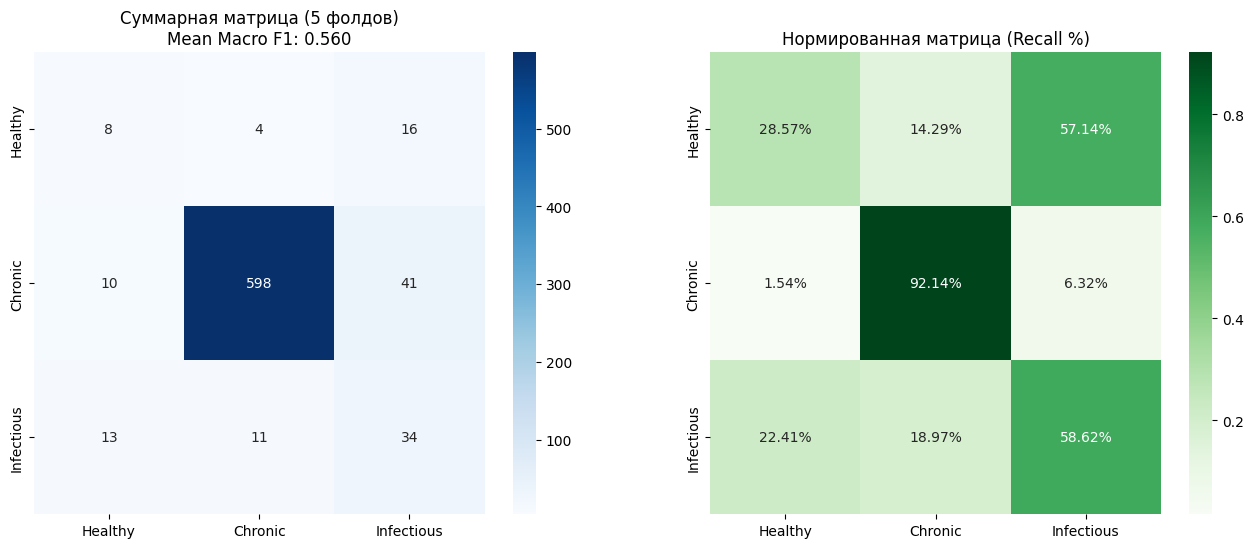

In [ ]:
def plot_cv_results(cm, f1_list):
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax[0],
        xticklabels=['Healthy', 'Chronic', 'Infectious'],
        yticklabels=['Healthy', 'Chronic', 'Infectious'],
    )
    ax[0].set_title(f'Aggregated confusion matrix (5 folds)\nMean Macro F1: {np.mean(f1_list):.3f}')

    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(
        cm_perc,
        annot=True,
        fmt='.2%',
        cmap='Greens',
        ax=ax[1],
        xticklabels=['Healthy', 'Chronic', 'Infectious'],
        yticklabels=['Healthy', 'Chronic', 'Infectious'],
    )
    ax[1].set_title('Normalized confusion matrix (Recall %)')

    plt.show()

plot_cv_results(total_cm, fold_f1)

## Part 8. Held-Out Test Evaluation

Evaluate the final stacked system on the 20% held-out test split after model training and threshold calibration.

In [ ]:
y_test_pred_3 = predict_3class(
    X_test_scaled,
    model_sick,
    model_inf,
    model_copd,
    model_multi_3,
    t_sick,
    t_inf,
    t_copd,
 )

print('Held-out test macro-F1:', f1_score(y_test_3class, y_test_pred_3, average='macro'))
print('Held-out test confusion matrix:')
print(confusion_matrix(y_test_3class, y_test_pred_3, labels=[0, 1, 2]))
print('Held-out test classification report:')
print(classification_report(
    y_test_3class,
    y_test_pred_3,
    labels=[0, 1, 2],
    target_names=['Healthy', 'Chronic', 'Infectious'],
    zero_division=0,
))

## Part 9. Inference Examples

Run single-row and mini-batch inference on the held-out test set to verify deployment-style usage.

In [ ]:
inv_label_map_3 = {0: 'Healthy', 1: 'Chronic', 2: 'Infectious'}

single_sample = X_test_scaled.iloc[[0]]
single_pred = predict_3class(
    single_sample,
    model_sick,
    model_inf,
    model_copd,
    model_multi_3,
    t_sick,
    t_inf,
    t_copd,
 )
single_prob = model_multi_3.predict_proba(single_sample)[0]

print('Single-sample predicted group:', inv_label_map_3[int(single_pred[0])])
print('Single-sample base stack probabilities [Healthy, Chronic, Infectious]:', single_prob)

batch_size = min(5, len(X_test_scaled))
batch_samples = X_test_scaled.iloc[:batch_size]
batch_pred = predict_3class(
    batch_samples,
    model_sick,
    model_inf,
    model_copd,
    model_multi_3,
    t_sick,
    t_inf,
    t_copd,
 )

batch_result = pd.DataFrame({
    'pred_group_id': batch_pred,
    'pred_group_name': [inv_label_map_3[int(x)] for x in batch_pred],
}, index=batch_samples.index)

display(batch_result)